# "Hand made" NUTS test

In order to compile this notebook it is needed to run the *NUTS_generalize.ipynb* notebbok ad use it as kernel for this one.

In [7]:
import arviz as az
import numpy as np
from scipy.stats import wishart

# Set random seed for reproducibility (same seed of Mattia's 250D notebook)
rng = np.random.default_rng(12345)

In [8]:
# body of the foor loop in the algorithm 3
def NUTS_one_step(L: Callable,
                  theta_0: jnp.ndarray,
                  epsilon: float,
                  key: jnp.ndarray,
                  j_max: int = 10):

    # 1. Sample momentum
    key, sub_r = jrnd.split(key)
    r_0 = jrnd.normal(sub_r, shape=theta_0.shape)

    # 2. Slice variable
    log_joint_0 = log_p(L, theta_0, r_0)
    key, sub_u = jrnd.split(key)
    u = jnp.exp(log_joint_0) * jrnd.uniform(sub_u)

    # 3. Initialize tree
    theta_minus = theta_0
    theta_plus  = theta_0
    r_minus     = r_0
    r_plus      = r_0
    theta_prime = theta_0
    n_prime     = jnp.array(1, dtype=jnp.int32)
    s_prime     = jnp.array(1, dtype=jnp.int32)
    alpha_sum   = jnp.array(0.0)
    n_alpha     = jnp.array(0, dtype=jnp.int32)

    # depth of the tree
    j = 0 

    # 4. Doubling
    while (s_prime == 1) & (j < j_max):

        # Choose a direction
        key, sub_v = jrnd.split(key)
        v_j = jnp.where(jrnd.uniform(sub_v) < 0.5, -1, 1)

        if v_j == -1:
            root = Root(theta_minus, r_minus, u, v_j, j, epsilon, theta_0, r_0)
        else:
            root = Root(theta_plus,  r_plus,  u, v_j, j, epsilon, theta_0, r_0)

        # Call the BuildTree function
        tree, key = BuildTree(L, root, key)

        if v_j == -1:
            theta_minus, r_minus = tree.theta_minus, tree.r_minus
        else:
            theta_plus,  r_plus  = tree.theta_plus,  tree.r_plus

        key, sub = jrnd.split(key)
        total_n = n_prime + tree.n_prime
        p = jnp.where(total_n > 0, tree.n_prime / total_n, 0.5)
        choose = jrnd.bernoulli(sub, p)
        theta_prime = jnp.where(choose, tree.theta_prime, theta_prime)

        n_prime   = n_prime + tree.n_prime
        s_prime   = s_prime * tree.s_prime * stop_criterion(
            theta_minus, theta_plus, r_minus, r_plus
        )
        alpha_sum = alpha_sum + tree.alpha_prime
        n_alpha   = n_alpha + tree.n_a_prime

        j += 1

    accept_rate = alpha_sum / jnp.maximum(1, n_alpha)
    return theta_prime, accept_rate, key


In [9]:
def NUTS_sampler(L: Callable,
                 theta_init: jnp.ndarray,
                 n_samples: int,
                 key: jnp.ndarray,
                 j_max: int = 10):

    epsilon = float(FindReasonableEpsilon(L, theta_init, key))

    thetas = []
    accs = []

    theta = theta_init

    for i in range(n_samples):
        theta, acc, key = NUTS_one_step(L, theta, epsilon, key, j_max=j_max)
        thetas.append(np.array(theta))
        accs.append(float(acc))

    return np.stack(thetas), np.array(accs), epsilon


In [10]:
# Define the pseudo log-potential
# Gaussian log-density
D = 10
df = D
A = wishart.rvs(df=df, scale=np.eye(D), random_state=rng).astype(np.float64)

@jax.jit
def L(theta: jnp.ndarray, precision_mat = A) -> jnp.float32:
    assert theta.ndim == 1
    return -0.5 * jnp.vdot(theta, precision_mat @ theta) 

In [11]:
dim = D
theta0 = jnp.zeros(dim)
key_0 = jrnd.PRNGKey(0)
key_1 = jrnd.PRNGKey(1)

# Build two chains with different key
samples_0, accs_0, eps_0 = NUTS_sampler(L, theta0, n_samples=1000, key=key_0)
samples_1, accs_1, eps_0 = NUTS_sampler(L, theta0, n_samples=1000, key=key_1)



NameError: name 'samples_chain1' is not defined

In [17]:
samples_0.shape = (1000, D)
samples_1.shape = (1000, D)

# Merge the sampled data
samples = np.stack([samples_0, samples_1])  

samples_flat = samples.reshape(-1, samples.shape[-1])
# shape = (2000, D)

print("epsilon:", eps_0)
print("mean:", samples_flat.mean(axis=0))
theta_mean = samples_flat.mean(axis=0)
print("cov:\n", np.cov(samples_flat.T))
cov_mat = np.cov(samples_flat, rowvar=False)
print("mean accept rate:", accs_0.mean())

epsilon: 0.25
mean: [-0.4592879  -0.0432945   0.03471447  0.10710555  0.28089762  0.43560272
 -0.4056751  -0.00918403  0.04782664  0.2877422 ]
cov:
 [[ 26.73475856   3.01007918  -4.56604636  -2.9032112  -11.83577519
  -22.20420578  17.95647448  -3.11131835  -2.81801958 -14.28558888]
 [  3.01007918   2.56233062   1.21574905   2.53680174   1.11845174
    2.6973651   -4.79248806   2.54043227  -4.29166408  -1.38548663]
 [ -4.56604636   1.21574905   3.51277289   2.14266747   2.77803401
    7.5848738   -6.88665777   4.62123926  -3.26754874   1.29282583]
 [ -2.9032112    2.53680174   2.14266747   5.01155076   5.68295556
   10.04129088 -12.51044511   3.50154982  -4.86918629   2.36639167]
 [-11.83577519   1.11845174   2.77803401   5.68295556   9.83992828
   16.76192629 -18.04258037   3.24762608  -2.93505726   7.73724966]
 [-22.20420578   2.6973651    7.5848738   10.04129088  16.76192629
   32.19366667 -32.88156812   9.61651701  -7.56498358  12.26797592]
 [ 17.95647448  -4.79248806  -6.88665777 

/home/pira/miniconda3/envs/inf/lib/python3.11/site-packages/arviz/plots/backends/matplotlib/pairplot.py:223: UserWarning: rcParams['plot.max_subplots'] (40) is smaller than the number of resulting pair plots with these variables, generating only a 8x8 grid
  warnings.warn(


array([[<Axes: ylabel='theta\n0, 0'>, <Axes: >, <Axes: >, <Axes: >,
        <Axes: >, <Axes: >, <Axes: >, <Axes: >],
       [<Axes: ylabel='theta\n0, 1'>, <Axes: >, <Axes: >, <Axes: >,
        <Axes: >, <Axes: >, <Axes: >, <Axes: >],
       [<Axes: ylabel='theta\n0, 2'>, <Axes: >, <Axes: >, <Axes: >,
        <Axes: >, <Axes: >, <Axes: >, <Axes: >],
       [<Axes: ylabel='theta\n0, 3'>, <Axes: >, <Axes: >, <Axes: >,
        <Axes: >, <Axes: >, <Axes: >, <Axes: >],
       [<Axes: ylabel='theta\n0, 4'>, <Axes: >, <Axes: >, <Axes: >,
        <Axes: >, <Axes: >, <Axes: >, <Axes: >],
       [<Axes: ylabel='theta\n0, 5'>, <Axes: >, <Axes: >, <Axes: >,
        <Axes: >, <Axes: >, <Axes: >, <Axes: >],
       [<Axes: ylabel='theta\n0, 6'>, <Axes: >, <Axes: >, <Axes: >,
        <Axes: >, <Axes: >, <Axes: >, <Axes: >],
       [<Axes: xlabel='theta\n0, 0', ylabel='theta\n0, 7'>,
        <Axes: xlabel='theta\n0, 1'>, <Axes: xlabel='theta\n0, 2'>,
        <Axes: xlabel='theta\n0, 3'>, <Axes: xlabel='

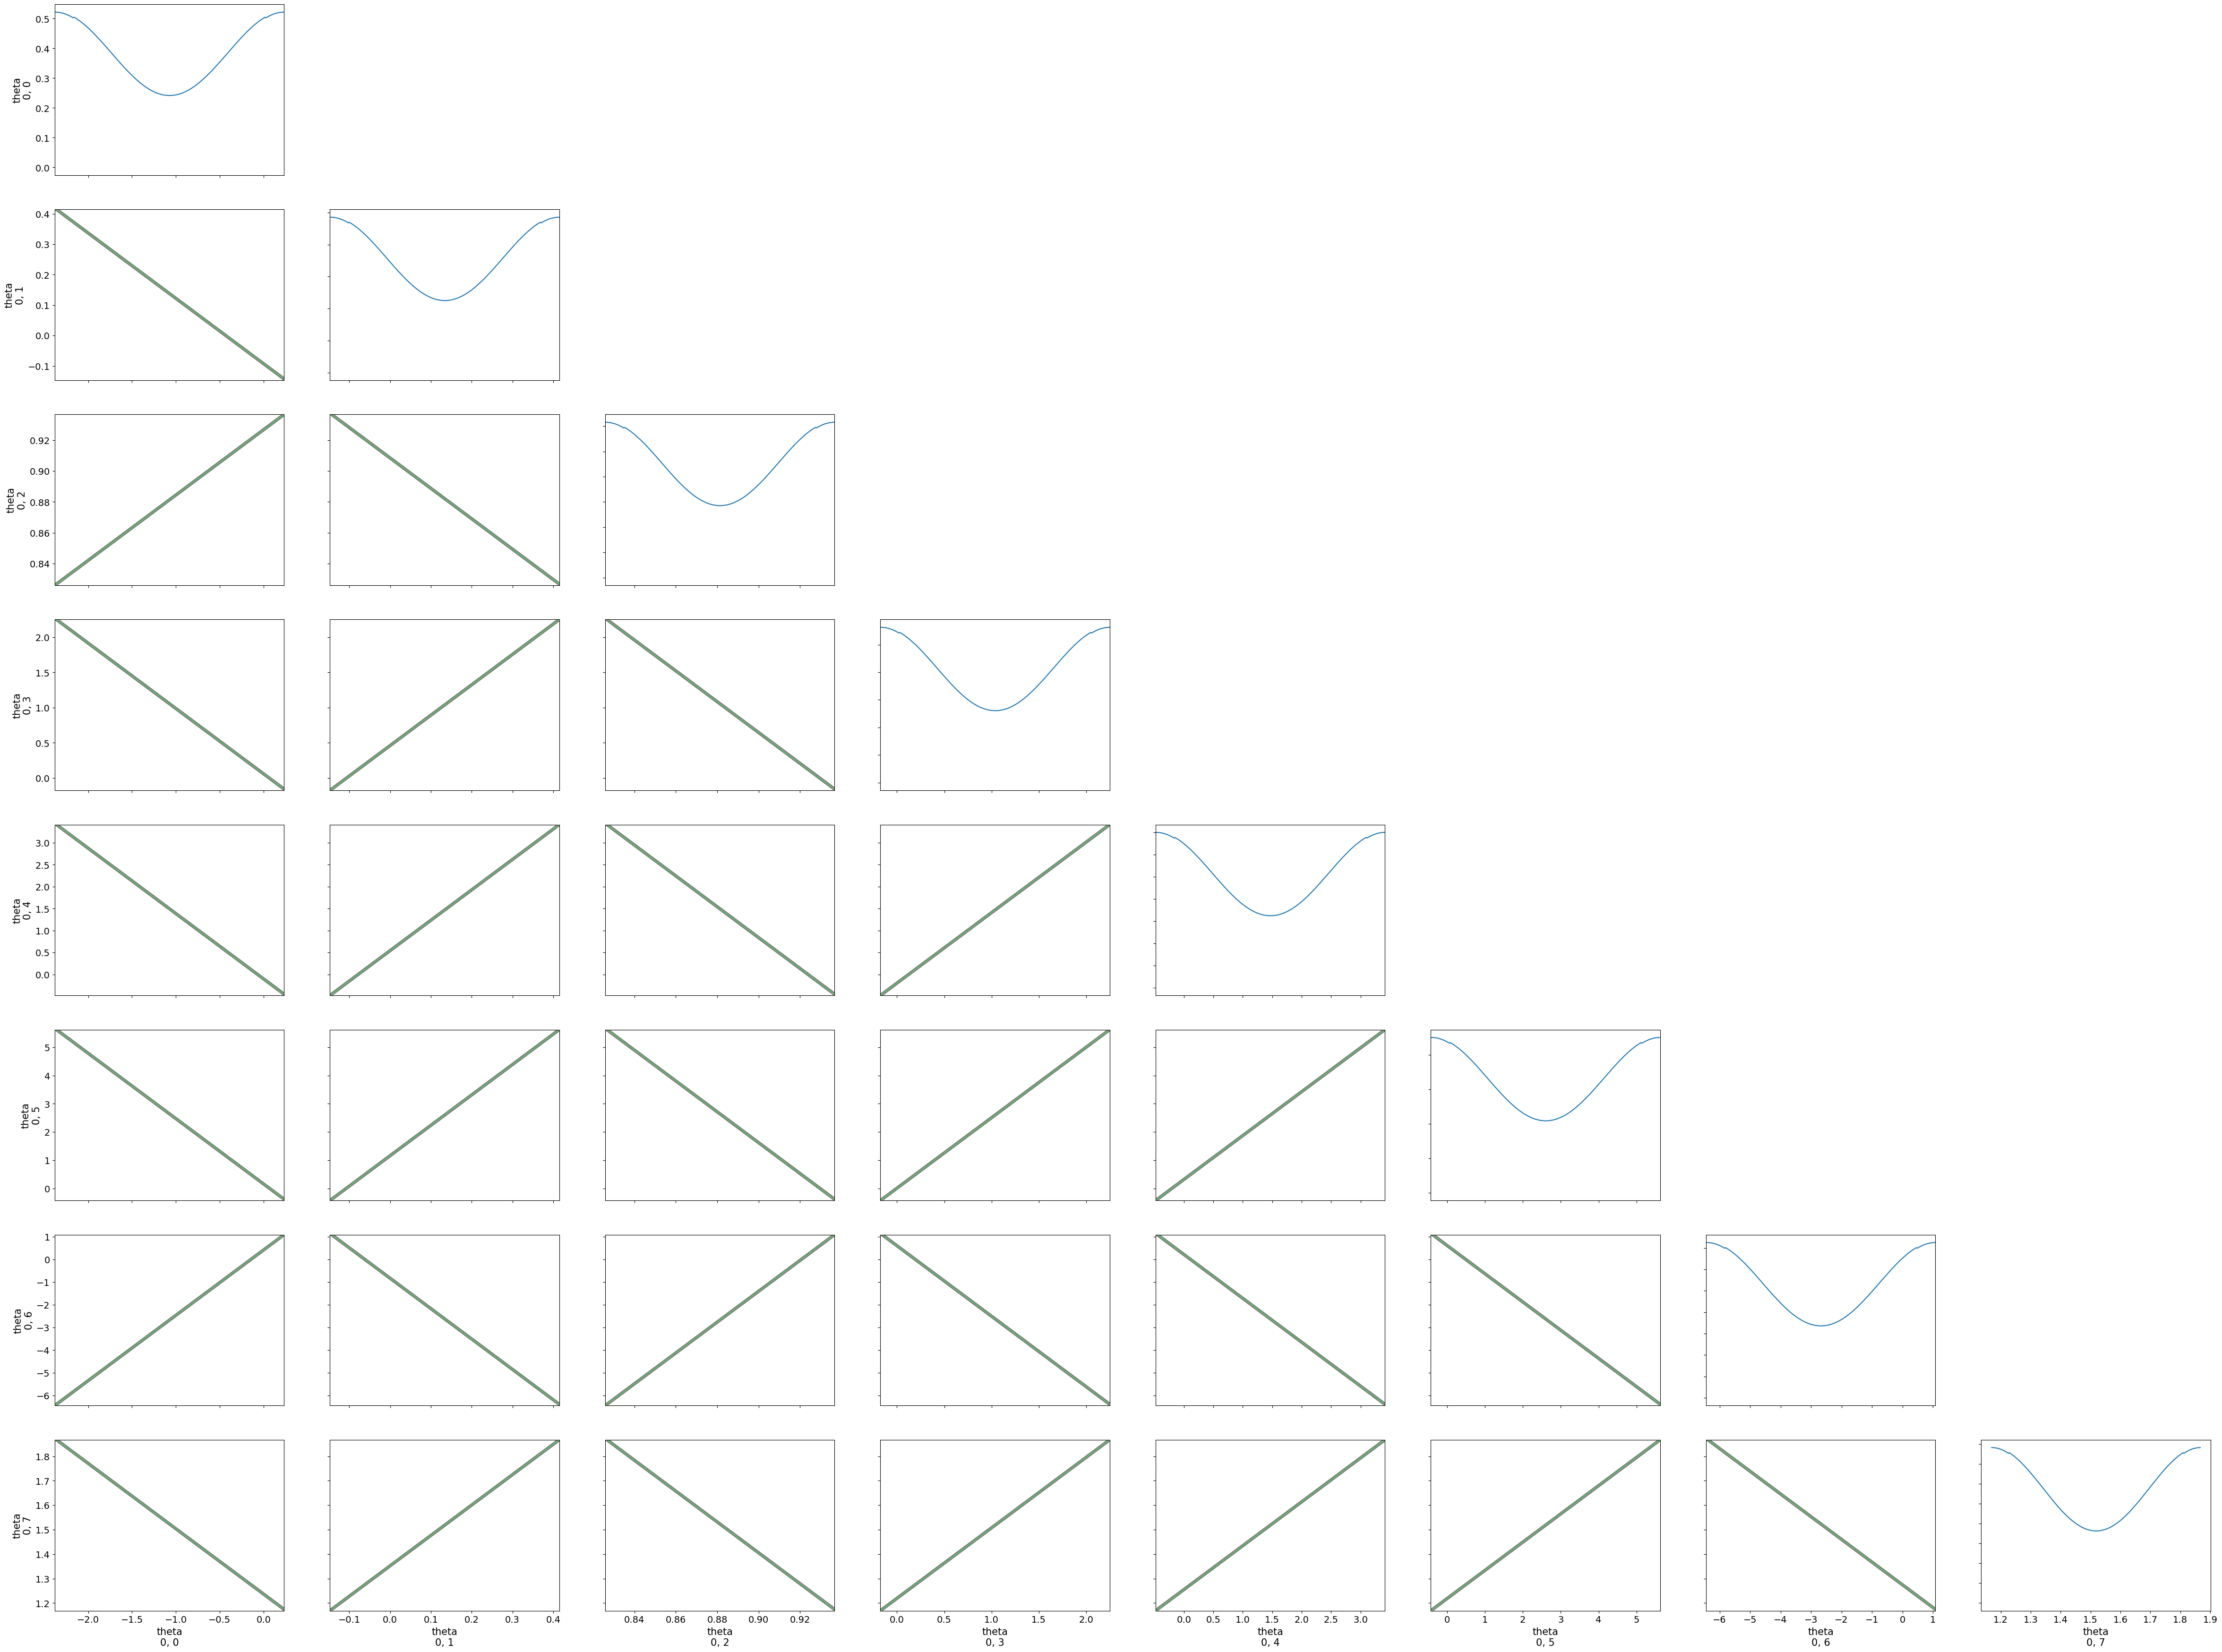

In [18]:
data_sample = samples[None, :, :]  

idata = az.from_dict(
    posterior={"theta": data_sample},
    coords={"theta_dim": np.arange(data_sample.shape[2])},
    dims={"theta": ["chain", "draw", "theta_dim"]},
)

az.plot_pair(idata, var_names=["theta"], kind="kde", marginals=True)

In [19]:
var_k = [ cov_mat[i,i] for i in range(D) ]
var_k

[np.float64(26.73475856101095),
 np.float64(2.5623306216257378),
 np.float64(3.512772888945388),
 np.float64(5.011550757833203),
 np.float64(9.83992828321992),
 np.float64(32.19366666583663),
 np.float64(36.902707607314824),
 np.float64(7.111932193957125),
 np.float64(8.202094886278916),
 np.float64(9.635882628110377)]

In [20]:
theta_mean

array([-0.4592879 , -0.0432945 ,  0.03471447,  0.10710555,  0.28089762,
        0.43560272, -0.4056751 , -0.00918403,  0.04782664,  0.2877422 ],
      dtype=float32)

In [21]:
import matplotlib.pyplot as plt

In [22]:
# The theorical variance of each variable comes from inverting the precision matrix A
th_cov_mat = np.linalg.inv(A)
th_var_k = [ th_cov_mat[i,i] for i in range(D) ]
th_var_k

[np.float64(17.781220345391976),
 np.float64(1.9501961907725307),
 np.float64(2.5902294511420303),
 np.float64(4.015257292735635),
 np.float64(7.262011257769527),
 np.float64(23.04232321265636),
 np.float64(27.67829581962921),
 np.float64(5.0749694070982105),
 np.float64(5.946110118780801),
 np.float64(6.420260710626618)]

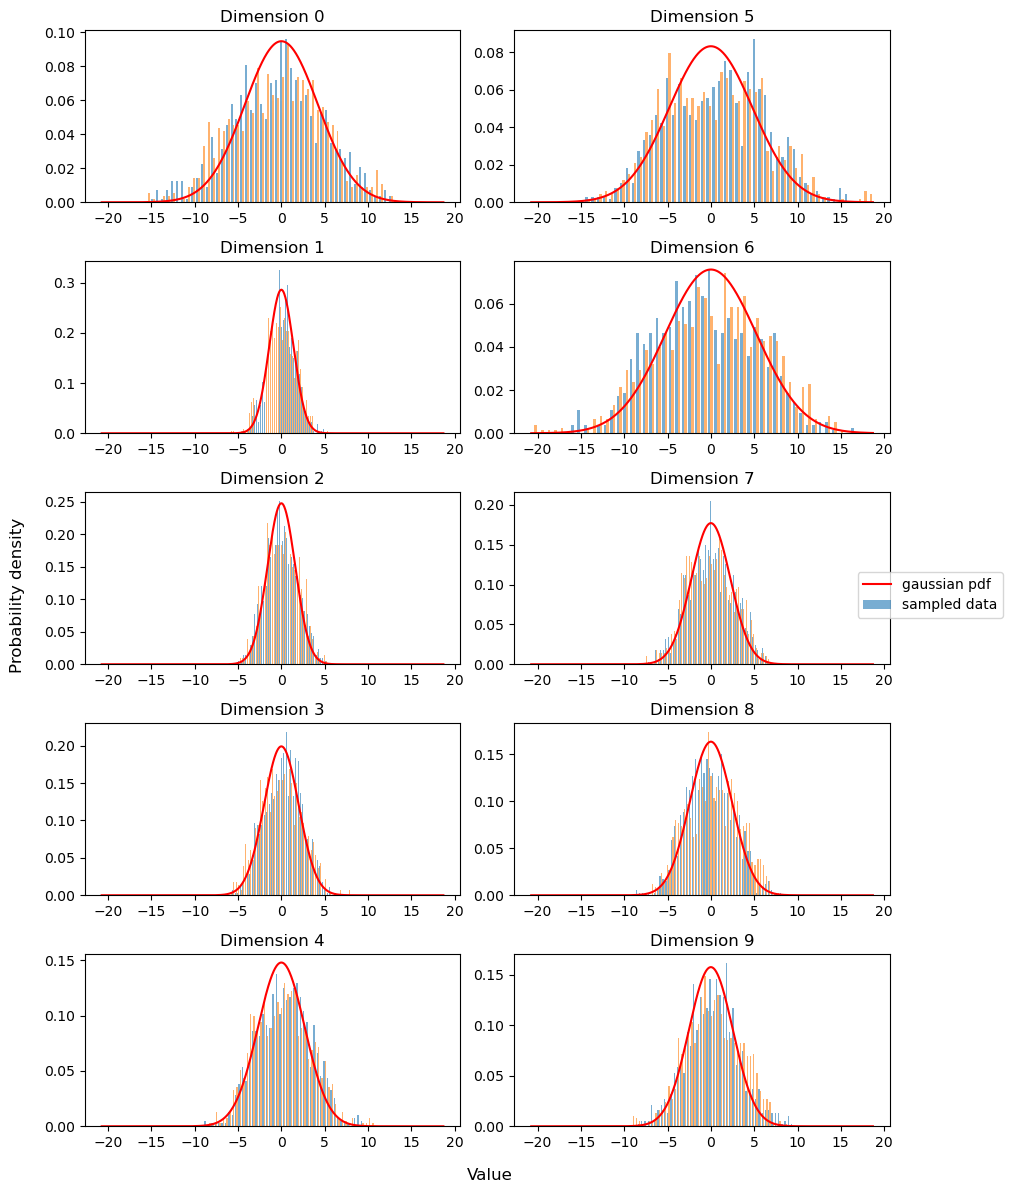

In [23]:
import numpy as np
import matplotlib.pyplot as plt
import math

x = np.linspace(samples.min(), samples.max(), 1000)

fig, axs = plt.subplots(5, 2, figsize=(10, 12))

for j in range(2):        # colonne
    for i in range(5):    # righe
        
        k = i + 5*j       # indice globale della variabile (0..9)

        var = th_var_k[k]
        norm_factor = 1 / math.sqrt(2 * np.pi * var)
        pdf = norm_factor * np.exp(-(x**2) / (2 * var))

        axs[i, j].plot(x, pdf, color='red', label='gaussian pdf')
        axs[i, j].hist(samples.T[k], bins=50, density=True, alpha=0.6, label='sampled data')

        axs[i, j].set_title(f"Dimension {k}")

# --- LEGENDA UNICA ---
handles, labels = axs[0,0].get_legend_handles_labels()
fig.legend(handles, labels, loc='center right', bbox_to_anchor=(1.02, 0.5))

# --- ETICHETTE GLOBALI ---
fig.supxlabel("Value")
fig.supylabel("Probability density")

plt.tight_layout()
plt.subplots_adjust(right=0.9)
plt.show()


## Comparing the "hand made" NUTS sampler with PyMC

In [24]:
import pymc as pm

In [25]:
# Perform the same sampling with a pyMC model => use A as precision matrix as before

N = A.shape[0]

with pm.Model() as model:
    theta = pm.MvNormal(
        "theta",
        mu=np.zeros(N),
        tau=A,   # <-- precision matrix
        shape=N
    )

    idata_pymc = pm.sample(
        draws=2000,
        tune=1000,
        chains=4,
        #nuts_sampler="numpyro",
        target_accept=0.9
    )


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [theta]
/home/pira/miniconda3/envs/inf/lib/python3.11/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()


Output()

/home/pira/miniconda3/envs/inf/lib/python3.11/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()


Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 13 seconds.


In [26]:
# Convert the data sampled by the custom algorithm in InferenceData
idata_custom = az.from_dict(
    posterior={"theta": samples[None, :, :]}
)

In [27]:
az.summary(idata_custom)
az.summary(idata_pymc)

arviz - WARNING - Shape validation failed: input_shape: (1, 2), minimum_shape: (chains=1, draws=4)


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
theta[0],0.030,4.226,-7.781,8.080,0.083,0.061,2592.0,3264.0,1.0
theta[1],0.038,1.372,-2.655,2.502,0.026,0.019,2758.0,3408.0,1.0
theta[2],0.017,1.614,-3.001,3.174,0.033,0.022,2369.0,3039.0,1.0
theta[3],0.043,1.973,-3.627,3.755,0.043,0.029,2129.0,2663.0,1.0
theta[4],0.031,2.680,-5.023,4.971,0.060,0.041,1995.0,2849.0,1.0
theta[5],0.062,4.796,-8.593,9.342,0.112,0.076,1837.0,2539.0,1.0
theta[6],-0.094,5.219,-9.992,9.493,0.121,0.082,1869.0,2704.0,1.0
theta[7],0.041,2.247,-4.002,4.488,0.047,0.032,2299.0,2730.0,1.0
theta[8],-0.069,2.407,-4.455,4.578,0.049,0.035,2369.0,3089.0,1.0
theta[9],-0.019,2.527,-5.120,4.454,0.050,0.034,2602.0,3641.0,1.0
